In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv(r'/Users/phamhoanghai/Ureca/dataset/output_data.csv')
df.head()

/var/folders/gp/sqskwmjx2zb7y096nd_t8_f80000gn/T/ipykernel_14197/385387956.py:1: DtypeWarning: Columns (0: WhiteElo, 1: BlackElo, 2: WhiteTitle) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'/Users/phamhoanghai/Ureca/dataset/output_data.csv')


,GameID,Event,Site,Date,Round,White,Black,Result,WhiteElo,BlackElo,...,BlackEloNumeric,EloDiff,AvgElo,NumericResult,PlyCount,MoveCount,MovesSAN,MovesUCI,FinalFEN,ExtraHeaders
0,1,Rated Bullet game,https://lichess.org/ZxvLJH20,????.??.??,?,sisy,lpaulmp,1-0,1645,1449,...,1449.0,196.0,1547.0,1.0,31,16,d4 e6 c4 d5 Nc3 dxc4 e4 c6 Bxc4 Nf6 e5 Nd5 Nxd...,d2d4 e7e6 c2c4 d7d5 b1c3 d5c4 e2e4 c7c6 f1c4 g...,r2q1rk1/1b2bppQ/p3p3/1p1pP3/2nP1P2/5N2/PPB3PP/...,{}
1,2,Rated Blitz game,https://lichess.org/1vAdLOmn,????.??.??,?,capablanca1950,ftri67,0-1,1603,1672,...,1672.0,-69.0,1637.5,0.0,4,2,e4 e6 d4 d5,e2e4 e7e6 d2d4 d7d5,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,{}
2,3,Rated Bullet game,https://lichess.org/s1RfrWEQ,????.??.??,?,daamien,mike81,1-0,1166,1280,...,1280.0,-114.0,1223.0,1.0,19,10,d4 d5 Bf4 c5 c3 Nc6 Nf3 e6 e3 Be7 Bb5 Nf6 O-O ...,d2d4 d7d5 c1f4 c7c5 c2c3 b8c6 g1f3 e7e6 e2e3 f...,r1bqnrk1/pp2bp1Q/2n1p1p1/1Bpp2N1/3P1B2/2P1P3/P...,{}
3,4,Rated Blitz game,https://lichess.org/4lE9x19F,????.??.??,?,yaavarmo,JACKELCALVO,1-0,1494,1449,...,1449.0,45.0,1471.5,1.0,81,41,e4 e6 d4 Ne7 g3 g6 Bg2 Bg7 e5 O-O Ne2 d6 exd6 ...,e2e4 e7e6 d2d4 g8e7 g2g3 g7g6 f1g2 f8g7 e4e5 e...,8/8/P7/5k2/1RB5/1P6/5P2/6K1 b - - 0 41,{}
4,5,Rated Bullet game,https://lichess.org/lVtEXmaA,????.??.??,?,albinofrenchy,galita,1-0,1256,1285,...,1285.0,-29.0,1270.5,1.0,59,30,d4 Nf6 c4 e6 Nc3 d5 Bg5 Be7 Nf3 Ne4 Nxe4 dxe4 ...,d2d4 g8f6 c2c4 e7e6 b1c3 d7d5 c1g5 f8e7 g1f3 f...,8/3b1qkp/p1nPpRp1/1pP1Q3/P5B1/4P3/6PP/6K1 b - ...,{}


In [17]:
player_game_counts = (
    pd.concat([
        df["White"].rename("Player"),
        df["Black"].rename("Player")
    ])
    .value_counts()
    .rename_axis("Player")
    .reset_index(name="GamesPlayed")
)

display(player_game_counts)
print((player_game_counts["GamesPlayed"] > 100).sum())


,Player,GamesPlayed
0,cocochess,6380
1,IgorKoc,5127
2,aavza50,4531
3,faryad22,3091
4,igo1,3031
...,...,...
30028,Still_NST,1
30029,penecornio,1
30030,fantanaranja,1
30031,sabou,1


5902


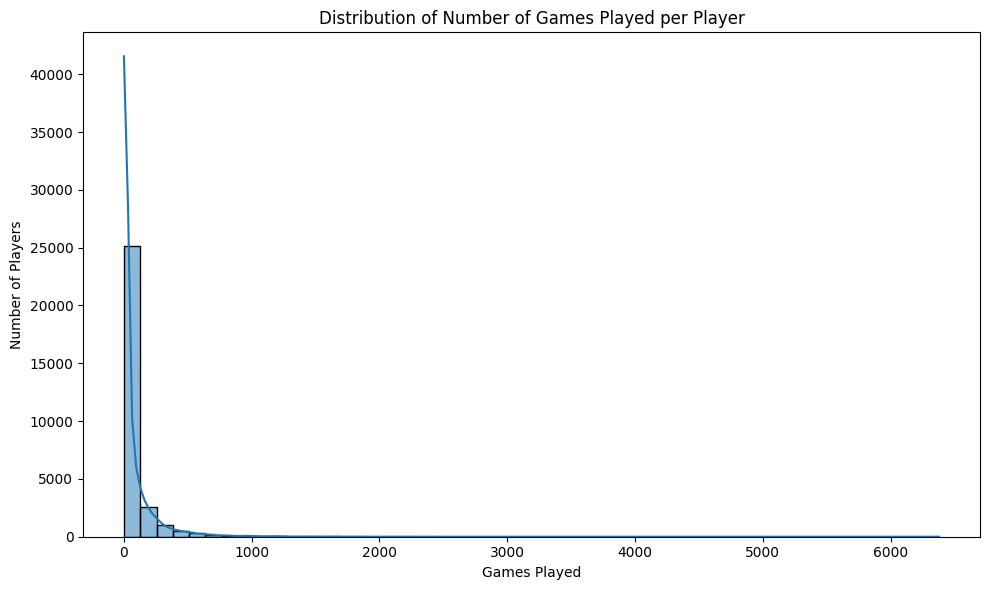

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(player_game_counts["GamesPlayed"], bins=50, kde=True)
plt.title("Distribution of Number of Games Played per Player")
plt.xlabel("Games Played")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.show()


In [9]:
csv_file_path = r"/Users/phamhoanghai/Ureca/dataset/output_data.csv"
df = pd.read_csv(csv_file_path)
print(df.head())

   WhiteElo  BlackElo  ECO  Result
0      1645      1449  D31     1.0
1      1603      1672  C00     0.0
2      1166      1280  D00     1.0
3      1494      1449  C00     1.0
4      1256      1285  D53     1.0


In [10]:
reference_df = pd.read_csv(r"D:\Dev\Projects\Ureca\dataset\big_elo_map.csv") 
merged_df = pd.merge(df, reference_df, left_on="ECO", right_on="code", how="left")
merged_df = merged_df.rename(columns={"name": "FullName"})
merged_df = merged_df.drop(columns=["code"])
merged_df["FullName"] = merged_df["FullName"].fillna("Unknown")

# Add opening family based on ECO code first letter
eco_family_map = {
    "A": "Flank Openings",
    "B": "Semi-Open Defenses",
    "C": "Open Games and Semi-Open",
    "D": "Closed and Semi-Closed",
    "E": "Indian Defenses",
}
merged_df["Opening_Family"] = merged_df["ECO"].str[0].map(eco_family_map).fillna("Unknown")

print(merged_df[["ECO", "Opening_Family", "FullName"]].head(10))
output_path = r"D:\Dev\Projects\Ureca\dataset\final_merged_data.csv"
merged_df.to_csv(output_path, index=False)
print(f"Matrix successfully saved to: {output_path}")

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Dev\\Projects\\Ureca\\dataset\\big_elo_map.csv'

In [5]:
file_path = r"D:\Dev\Projects\Ureca\dataset\final_merged_data.csv"
df = pd.read_csv(file_path)

# 2. Ensure Elo columns are strictly numeric vectors
# 'coerce' turns any accidental string artifacts (like '?') into NaN so we can drop them cleanly
df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
df['BlackElo'] = pd.to_numeric(df['BlackElo'], errors='coerce')
df = df.dropna(subset=['WhiteElo', 'BlackElo'])

# 3. Feature Engineering: Calculate continuous variables
df['Elo_Diff'] = df['WhiteElo'] - df['BlackElo']
df['Avg_Elo'] = (df['WhiteElo'] + df['BlackElo']) / 2

# Verify the matrix structure and the remaining sample size
print(df.head())
print(f"\nTotal decisive games remaining for the model: {len(df)}")

   WhiteElo  BlackElo  ECO  Result                             FullName  \
0      1645      1449  D31     1.0                           QGD, 3.Nc3   
1      1603      1672  C00     0.0  French Defense, Irregular Responses   
2      1166      1280  D00     1.0     Closed Game, Irregular Responses   
3      1494      1449  C00     1.0  French Defense, Irregular Responses   
4      1256      1285  D53     1.0                       QGD; 4.Bg5 Be7   

             Opening_Family  Elo_Diff  Avg_Elo  
0    Closed and Semi-Closed       196   1547.0  
1  Open Games and Semi-Open       -69   1637.5  
2    Closed and Semi-Closed      -114   1223.0  
3  Open Games and Semi-Open        45   1471.5  
4    Closed and Semi-Closed       -29   1270.5  

Total decisive games remaining for the model: 1111082


In [6]:
output_path = r"D:\Dev\Projects\Ureca\dataset\final_merged_data.csv"
df.to_csv(output_path, index=False)
print(f"Matrix successfully saved to: {output_path}")

Matrix successfully saved to: D:\Dev\Projects\Ureca\dataset\final_merged_data.csv


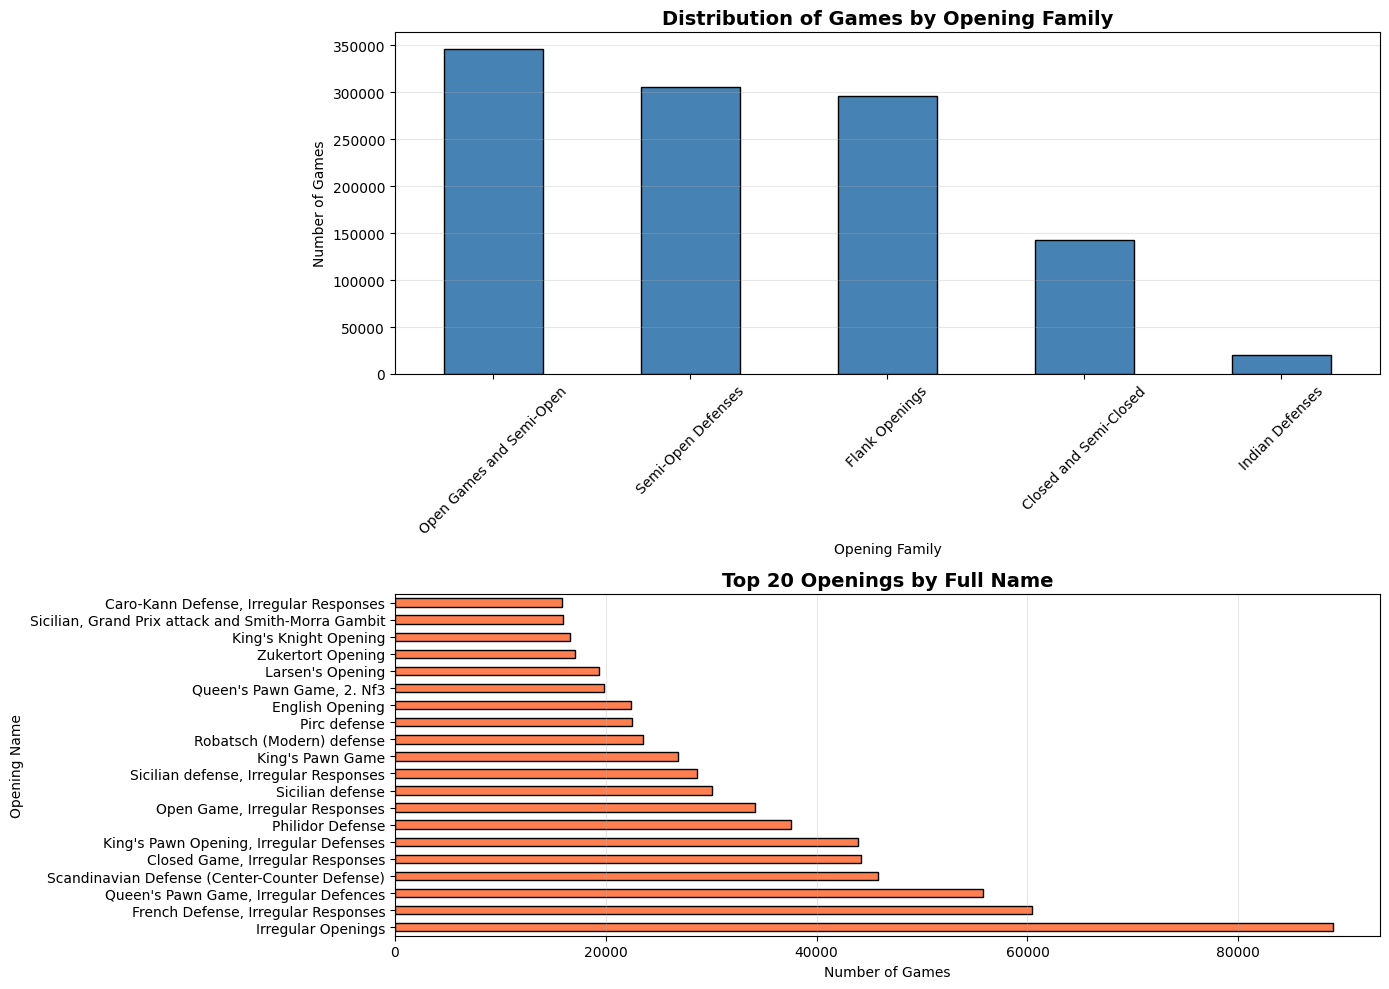


=== Opening Family Distribution ===
Opening_Family
Open Games and Semi-Open    346566
Semi-Open Defenses          306168
Flank Openings              296020
Closed and Semi-Closed      142490
Indian Defenses              19838
Name: count, dtype: int64

Total families: 5

=== Top 15 Openings by Name ===
FullName
Irregular Openings                               88988
French Defense, Irregular Responses              60419
Queen's Pawn Game, Irregular Defences            55771
Scandinavian Defense (Center-Counter Defense)    45819
Closed Game, Irregular Responses                 44242
King's Pawn Opening, Irregular Defenses          43944
Philidor Defense                                 37600
Open Game, Irregular Responses                   34125
Sicilian defense                                 30061
Sicilian defense, Irregular Responses            28611
King's Pawn Game                                 26859
Robatsch (Modern) defense                        23514
Pirc defense              

In [8]:
# Load the final data with Opening_Family column
df_final = pd.read_csv(r"D:\Dev\Projects\Ureca\dataset\final_merged_data.csv")

# Plot 1: Distribution of games by Opening Family
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Count by Opening Family
family_counts = df_final['Opening_Family'].value_counts().sort_values(ascending=False)
family_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Games by Opening Family', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Opening Family')
axes[0].set_ylabel('Number of Games')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Count by FullName (top 20)
name_counts = df_final['FullName'].value_counts().head(20)
name_counts.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 20 Openings by Full Name', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Games')
axes[1].set_ylabel('Opening Name')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Opening Family Distribution ===")
print(family_counts)
print(f"\nTotal families: {len(family_counts)}")

print("\n=== Top 15 Openings by Name ===")
print(df_final['FullName'].value_counts().head(15))
print(f"\nTotal unique openings: {df_final['FullName'].nunique()}")

In [9]:
# Count openings by FullName with game thresholds
opening_counts = df_final['FullName'].value_counts().reset_index()
opening_counts.columns = ['FullName', 'Games']

# Count openings with games < 100 and < 1000
count_lt_100 = (opening_counts['Games'] < 100).sum()
count_lt_1000 = (opening_counts['Games'] < 1000).sum()

print("=== Opening Count Statistics ===")
print(f"Total unique openings: {len(opening_counts)}")
print(f"\nOpenings with < 100 games: {count_lt_100}")
print(f"Openings with < 1000 games: {count_lt_1000}")
print(f"Openings with >= 1000 games: {len(opening_counts) - count_lt_1000}")

print("\n=== Openings with < 100 games ===")
print(opening_counts[opening_counts['Games'] < 100].sort_values('Games', ascending=False).head(20))

print("\n=== Distribution Summary ===")
print(f"Min games per opening: {opening_counts['Games'].min()}")
print(f"Max games per opening: {opening_counts['Games'].max()}")
print(f"Mean games per opening: {opening_counts['Games'].mean():.2f}")
print(f"Median games per opening: {opening_counts['Games'].median():.2f}")

=== Opening Count Statistics ===
Total unique openings: 433

Openings with < 100 games: 192
Openings with < 1000 games: 321
Openings with >= 1000 games: 112

=== Openings with < 100 games ===
                                              FullName  Games
241                  Nimzo-Indian, Spielmann variation     99
242          Nimzo-Indian, Saemisch variation, 5...0-0     98
243                               QGD; Dutch variation     97
244                   King's Indian, Sämisch variation     96
245                               QGD; Semi-Slav 7.Bc4     95
246                            Ruy Lopez, Closed, 9.h3     93
247  King's Indian, Orthodox, Aronin-Taimanov varia...     91
248                            Sicilian, Najdorf, 6.f4     89
249                       Grünfeld with 5.Bf4 O-O 6.e3     88
250              Sicilian, Dragon, Levenfish variation     86
251      French, Tarrasch, Closed Variation, Main line     85
252             Nimzo-Indian, Classical, Noa variation     85
25

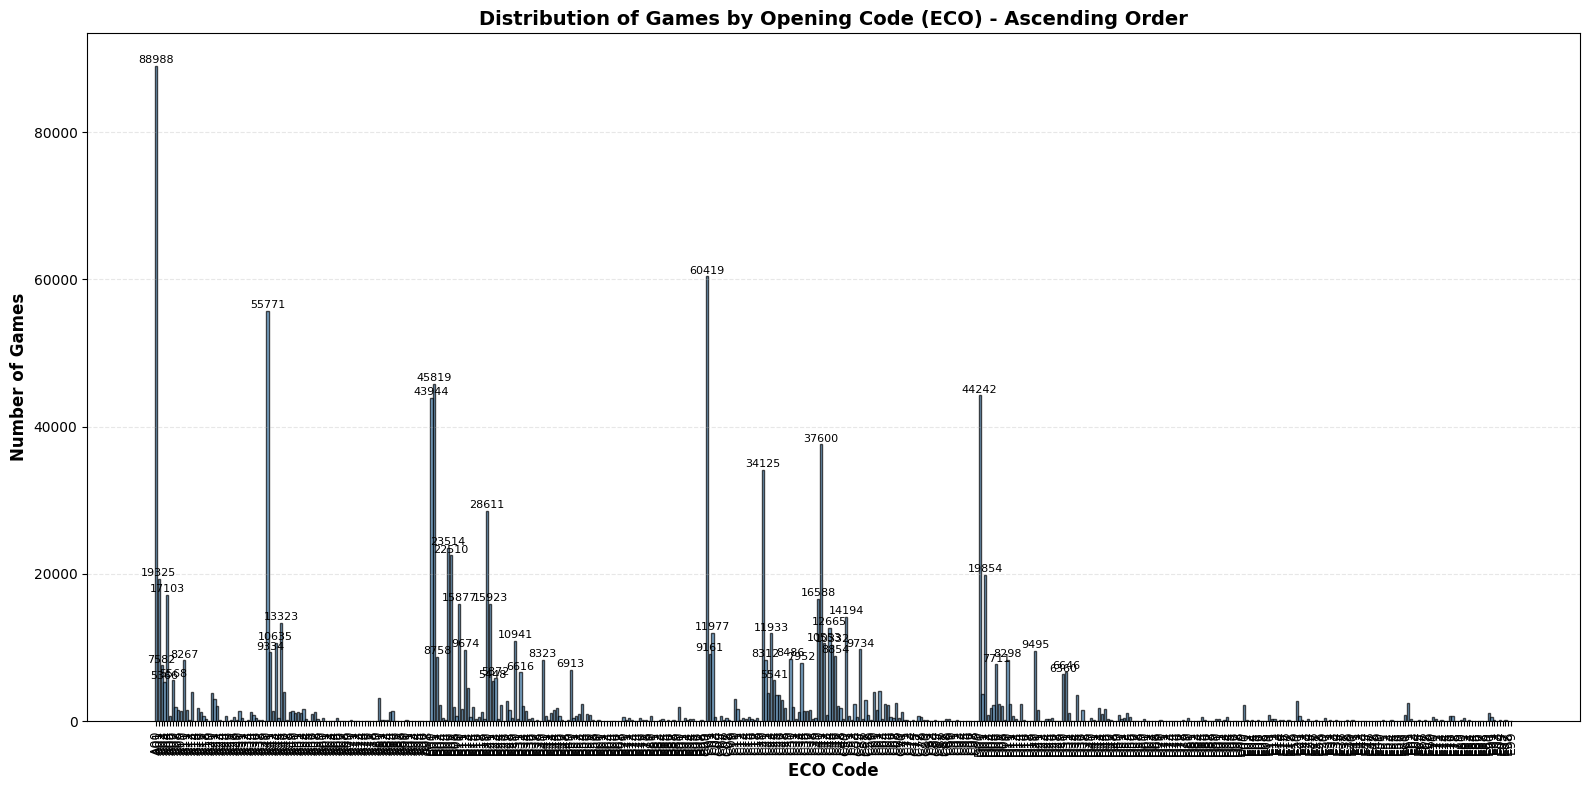


=== ECO Code Statistics (Ascending Order) ===
     ECO  Games
0    A00  88988
12   A01  19325
40   A02   7582
49   A03   5366
13   A04  17103
..   ...    ...
237  E94    186
426  E95     11
291  E97     91
309  E98     74
355  E99     39

[488 rows x 2 columns]

Total unique ECO codes: 488

Top 10 ECO codes by game count:
   ECO  Games
0  A00  88988
1  C00  60419
2  A40  55771
3  B01  45819
4  D00  44242
5  B00  43944
6  C41  37600
7  C20  34125
8  B20  28611
9  B06  23514

Bottom 10 ECO codes by game count (least played):
     ECO  Games
487  A78      1
486  A79      1
481  D72      1
479  E44      1
484  D49      1
480  B66      1
483  E45      1
485  D99      1
482  D28      1
473  D29      2


In [10]:
# Plot distribution of games by ECO code in ascending order
eco_counts = df_final['ECO'].value_counts().reset_index()
eco_counts.columns = ['ECO', 'Games']
eco_counts = eco_counts.sort_values('ECO', ascending=True)

# Create a large figure to accommodate all ECO codes
fig, ax = plt.subplots(figsize=(16, 8))

# Create bar chart
bars = ax.bar(range(len(eco_counts)), eco_counts['Games'], color='steelblue', edgecolor='black', alpha=0.7)

# Customize the plot
ax.set_xlabel('ECO Code', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Games', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Games by Opening Code (ECO) - Ascending Order', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(eco_counts)))
ax.set_xticklabels(eco_counts['ECO'], rotation=90, fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars for major values
for i, (idx, row) in enumerate(eco_counts.iterrows()):
    if row['Games'] > 5000:  # Only label bars with > 5000 games
        ax.text(i, row['Games'] + 100, str(int(row['Games'])), 
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics by ECO code
print("\n=== ECO Code Statistics (Ascending Order) ===")
print(eco_counts.sort_values('ECO', ascending=True))

print(f"\nTotal unique ECO codes: {len(eco_counts)}")
print(f"\nTop 10 ECO codes by game count:")
print(eco_counts.sort_values('Games', ascending=False).head(10))

print(f"\nBottom 10 ECO codes by game count (least played):")
print(eco_counts.sort_values('Games', ascending=True).head(10))

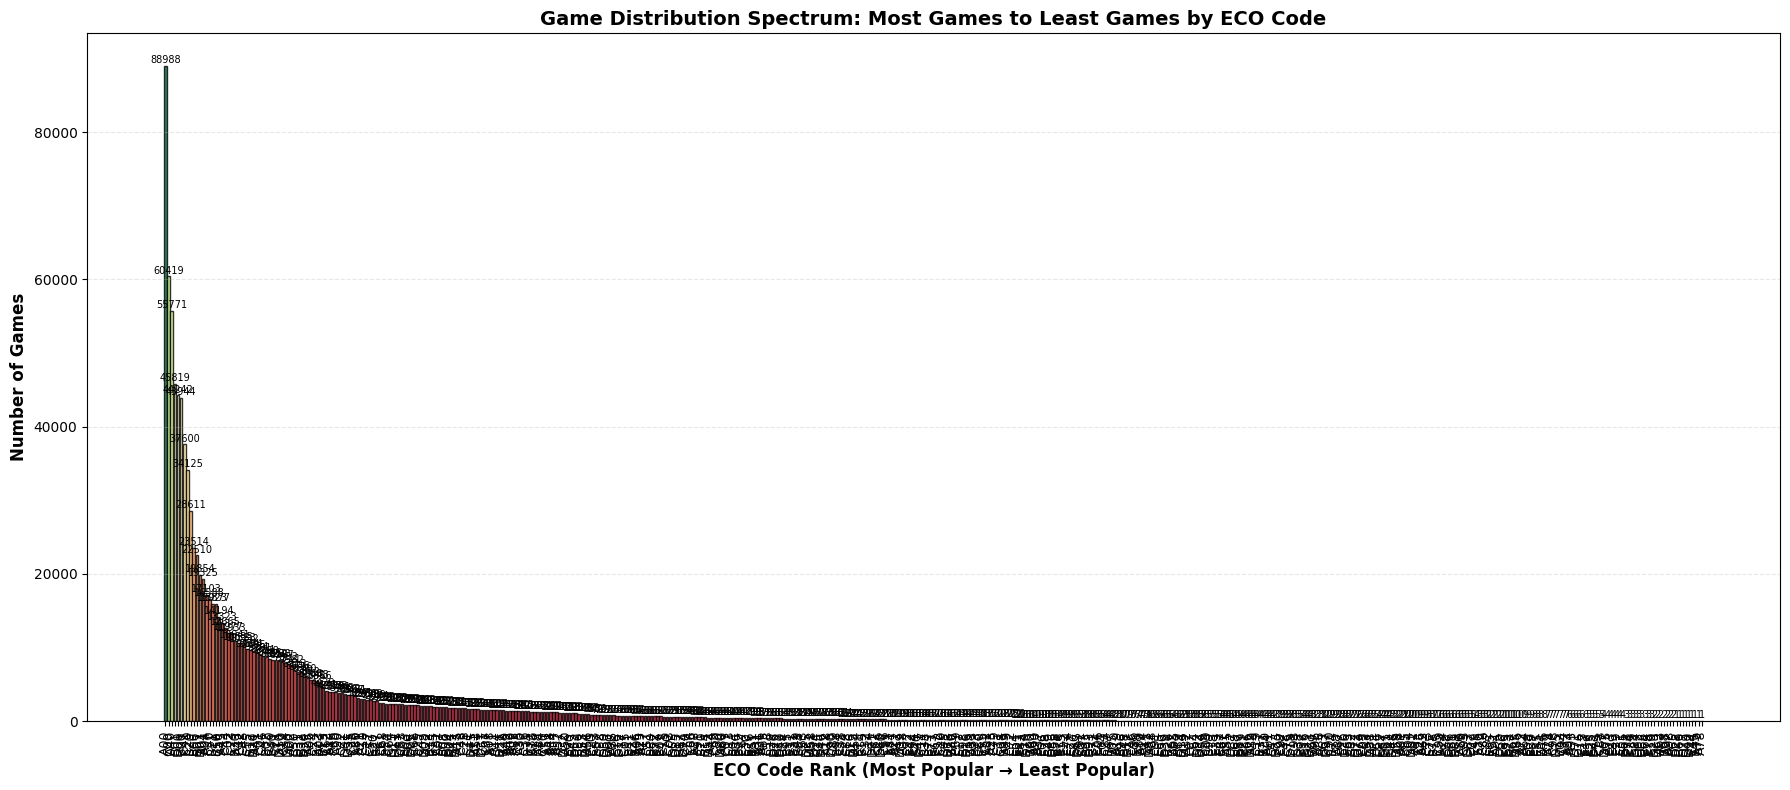


=== ECO Code Ranking by Game Count (Most to Least) ===
ECO  Games
A00  88988
C00  60419
A40  55771
B01  45819
D00  44242
B00  43944
C41  37600
C20  34125
B20  28611
B06  23514
B07  22510
D02  19854
A01  19325
A04  17103
C40  16588
B21  15923
B10  15877
C50  14194
A45  13323
C44  12665
C02  11977
C23  11933
B30  10941
A43  10635
C42  10553
C45  10332
C55   9734
B12   9674
D20   9495
A41   9334
C01   9161
C46   8854
B02   8758
C30   8486
B40   8323
C21   8312
D10   8298
A10   8267
C34   7952
D06   7711
A02   7582
B50   6913
D31   6646
B32   6616
D30   6360
B23   5872
A06   5568
C24   5541
B22   5448
A03   5366
B13   4429
C62   4141
A13   4020
A46   3955
C60   3938
A20   3791
C22   3755
D01   3616
D35   3532
C25   3507
C26   3481
A80   3097
A21   3041
C10   2960
C27   2929
C57   2849
E20   2789
B27   2674
E61   2492
C68   2455
B54   2390
C64   2368
D15   2322
D11   2295
D07   2273
C53   2270
B03   2195
E00   2193
D05   2153
C65   2138
B25   2120
C47   2112
D08   2065
A22   2012
B33   198

In [11]:
# Plot spectrum from most games to least games (sorted by descending game count)
eco_counts_sorted = eco_counts.sort_values('Games', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(18, 8))

# Create color gradient based on game count
colors = plt.cm.RdYlGn(eco_counts_sorted['Games'] / eco_counts_sorted['Games'].max())

# Create bar chart
bars = ax.bar(range(len(eco_counts_sorted)), eco_counts_sorted['Games'], 
              color=colors, edgecolor='black', alpha=0.8)

# Customize the plot
ax.set_xlabel('ECO Code Rank (Most Popular → Least Popular)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Games', fontsize=12, fontweight='bold')
ax.set_title('Game Distribution Spectrum: Most Games to Least Games by ECO Code', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(eco_counts_sorted)))
ax.set_xticklabels(eco_counts_sorted['ECO'], rotation=90, fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of all bars
for i, (idx, row) in enumerate(eco_counts_sorted.iterrows()):
    ax.text(i, row['Games'] + 100, f"{int(row['Games'])}", 
            ha='center', va='bottom', fontsize=7, rotation=0)

plt.tight_layout()
plt.show()

# Print summary
print("\n=== ECO Code Ranking by Game Count (Most to Least) ===")
print(eco_counts_sorted[['ECO', 'Games']].to_string(index=False))

print(f"\n=== Summary Statistics ===")
print(f"Most played ECO code: {eco_counts_sorted.iloc[0]['ECO']} with {int(eco_counts_sorted.iloc[0]['Games'])} games")
print(f"Least played ECO code: {eco_counts_sorted.iloc[-1]['ECO']} with {int(eco_counts_sorted.iloc[-1]['Games'])} games")
print(f"Average games per ECO code: {eco_counts_sorted['Games'].mean():.0f}")
print(f"Median games per ECO code: {eco_counts_sorted['Games'].median():.0f}")

# Cumulative percentage
eco_counts_sorted['Cumulative_Pct'] = 100 * eco_counts_sorted['Games'].cumsum() / eco_counts_sorted['Games'].sum()
print(f"\nTop 20 ECO codes account for {eco_counts_sorted.iloc[19]['Cumulative_Pct']:.1f}% of all games")
print(f"Top 50 ECO codes account for {eco_counts_sorted.iloc[min(49, len(eco_counts_sorted)-1)]['Cumulative_Pct']:.1f}% of all games")

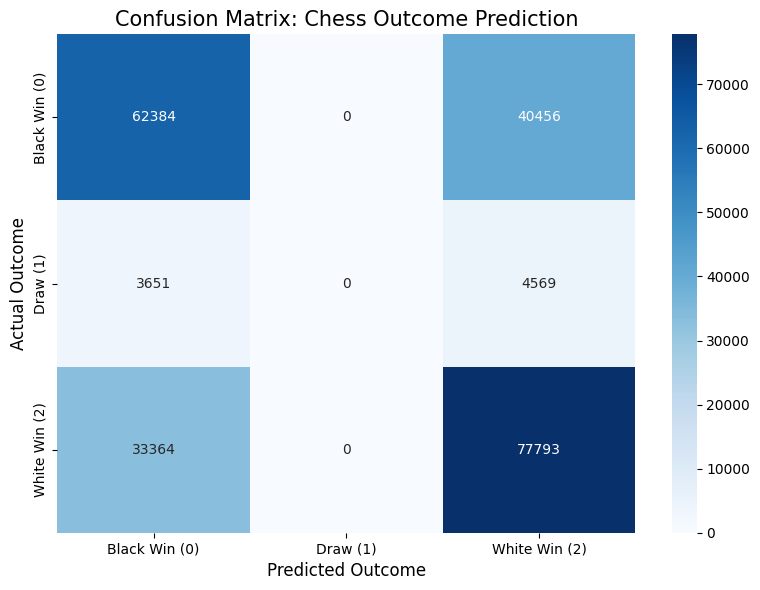

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_test_int, y_pred)

# 2. Define the labels for the axes
labels = ['Black Win (0)', 'Draw (1)', 'White Win (2)']

# 3. Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,               # Show the actual numbers in the cells
    fmt='d',                  # Format as integers
    cmap='Blues',             # Color scheme
    xticklabels=labels, 
    yticklabels=labels
)

# 4. Add titles and labels
plt.title('Confusion Matrix: Chess Outcome Prediction', fontsize=15)
plt.xlabel('Predicted Outcome', fontsize=12)
plt.ylabel('Actual Outcome', fontsize=12)

# Save or show the plot
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

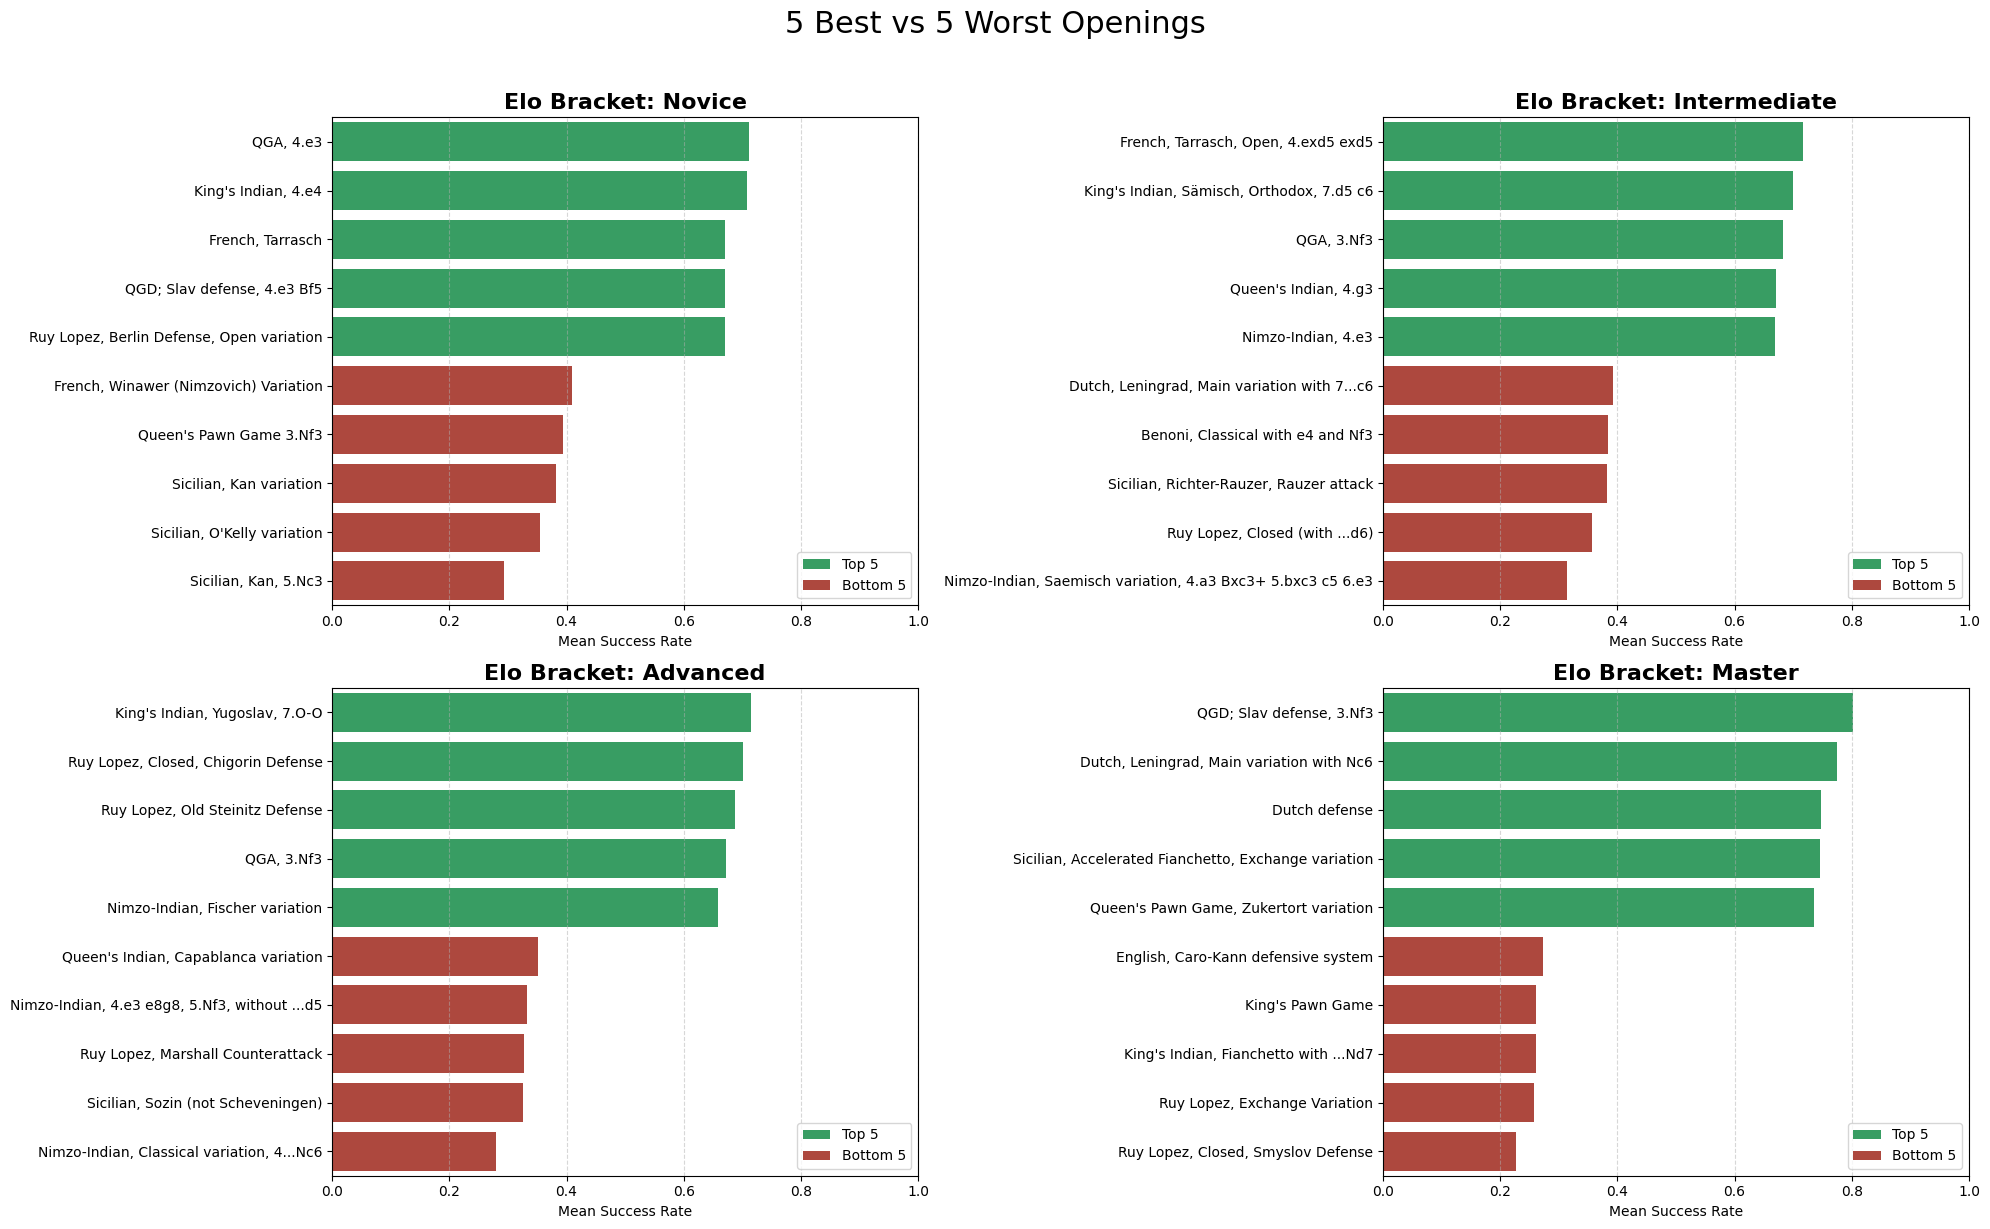

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Lowering the threshold to 10 to ensure we get data
# You can raise this back up once you confirm the charts work
min_games = 10 

# 2. Calculate stats and filter
stats = X_train.groupby(['Elo_Bracket', 'FullName'])['ECO_Contextual'].agg(['mean', 'count']).reset_index()
significant_stats = stats[stats['count'] >= min_games]

# 3. Dynamically get the brackets that actually exist in your data
# This prevents the "Insufficient Data" error caused by naming mismatches
brackets = significant_stats['Elo_Bracket'].unique()
num_brackets = len(brackets)

# 4. Create subplots based on how many brackets we found
fig, axes = plt.subplots(nrows=(num_brackets + 1) // 2, ncols=2, figsize=(20, 6 * ((num_brackets + 1) // 2)))
axes = axes.flatten()

for i, bracket in enumerate(brackets):
    # Filter for the specific bracket
    bracket_data = significant_stats[significant_stats['Elo_Bracket'] == bracket].sort_values('mean', ascending=False)
    
    # Check if we have enough openings to show a Top/Bottom split
    if len(bracket_data) >= 2:
        # Take up to top 5 and bottom 5 (using min to avoid errors if there are only 6 total)
        n = min(5, len(bracket_data) // 2)
        top_n = bracket_data.head(n).copy()
        bottom_n = bracket_data.tail(n).copy()
        
        top_n['Performance'] = f'Top {n}'
        bottom_n['Performance'] = f'Bottom {n}'
        plot_df = pd.concat([top_n, bottom_n])
        
        sns.barplot(
            data=plot_df,
            x='mean',
            y='FullName',
            hue='Performance',
            ax=axes[i],
            palette={'Top ' + str(n): '#27ae60', 'Bottom ' + str(n): '#c0392b'},
            dodge=False
        )
        
        axes[i].set_title(f'Elo Bracket: {bracket}', fontsize=16, fontweight='bold')
        axes[i].set_xlabel('Mean Success Rate')
        axes[i].set_ylabel('')
        axes[i].set_xlim(0, 1)
        axes[i].grid(axis='x', linestyle='--', alpha=0.5)
        axes[i].legend(loc='lower right')
    else:
        axes[i].text(0.5, 0.5, f'Only {len(bracket_data)} openings found\nTry lowering min_games', 
                     ha='center', va='center', fontsize=12)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('5 Best vs 5 Worst Openings', fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# 1. Group games by player (White) and sort to see their opening history
# We assume your 'main_df' has a 'White' (username) and 'ECO' column
# If you don't have usernames, this aim requires re-extracting the 'White' and 'Black' headers from your PGN.

player_history = df.groupby('WhiteElo')['ECO'].apply(list).reset_index()

# 2. Function to find the 'Most Frequent' opening and 'Last Used' opening
def get_behavioral_features(history):
    if len(history) < 2:
        return None
    last_opening = history[-1]
    previous_opening = history[-2]
    return pd.Series([last_opening, previous_opening])

# This allows us to see if players repeat their last choice

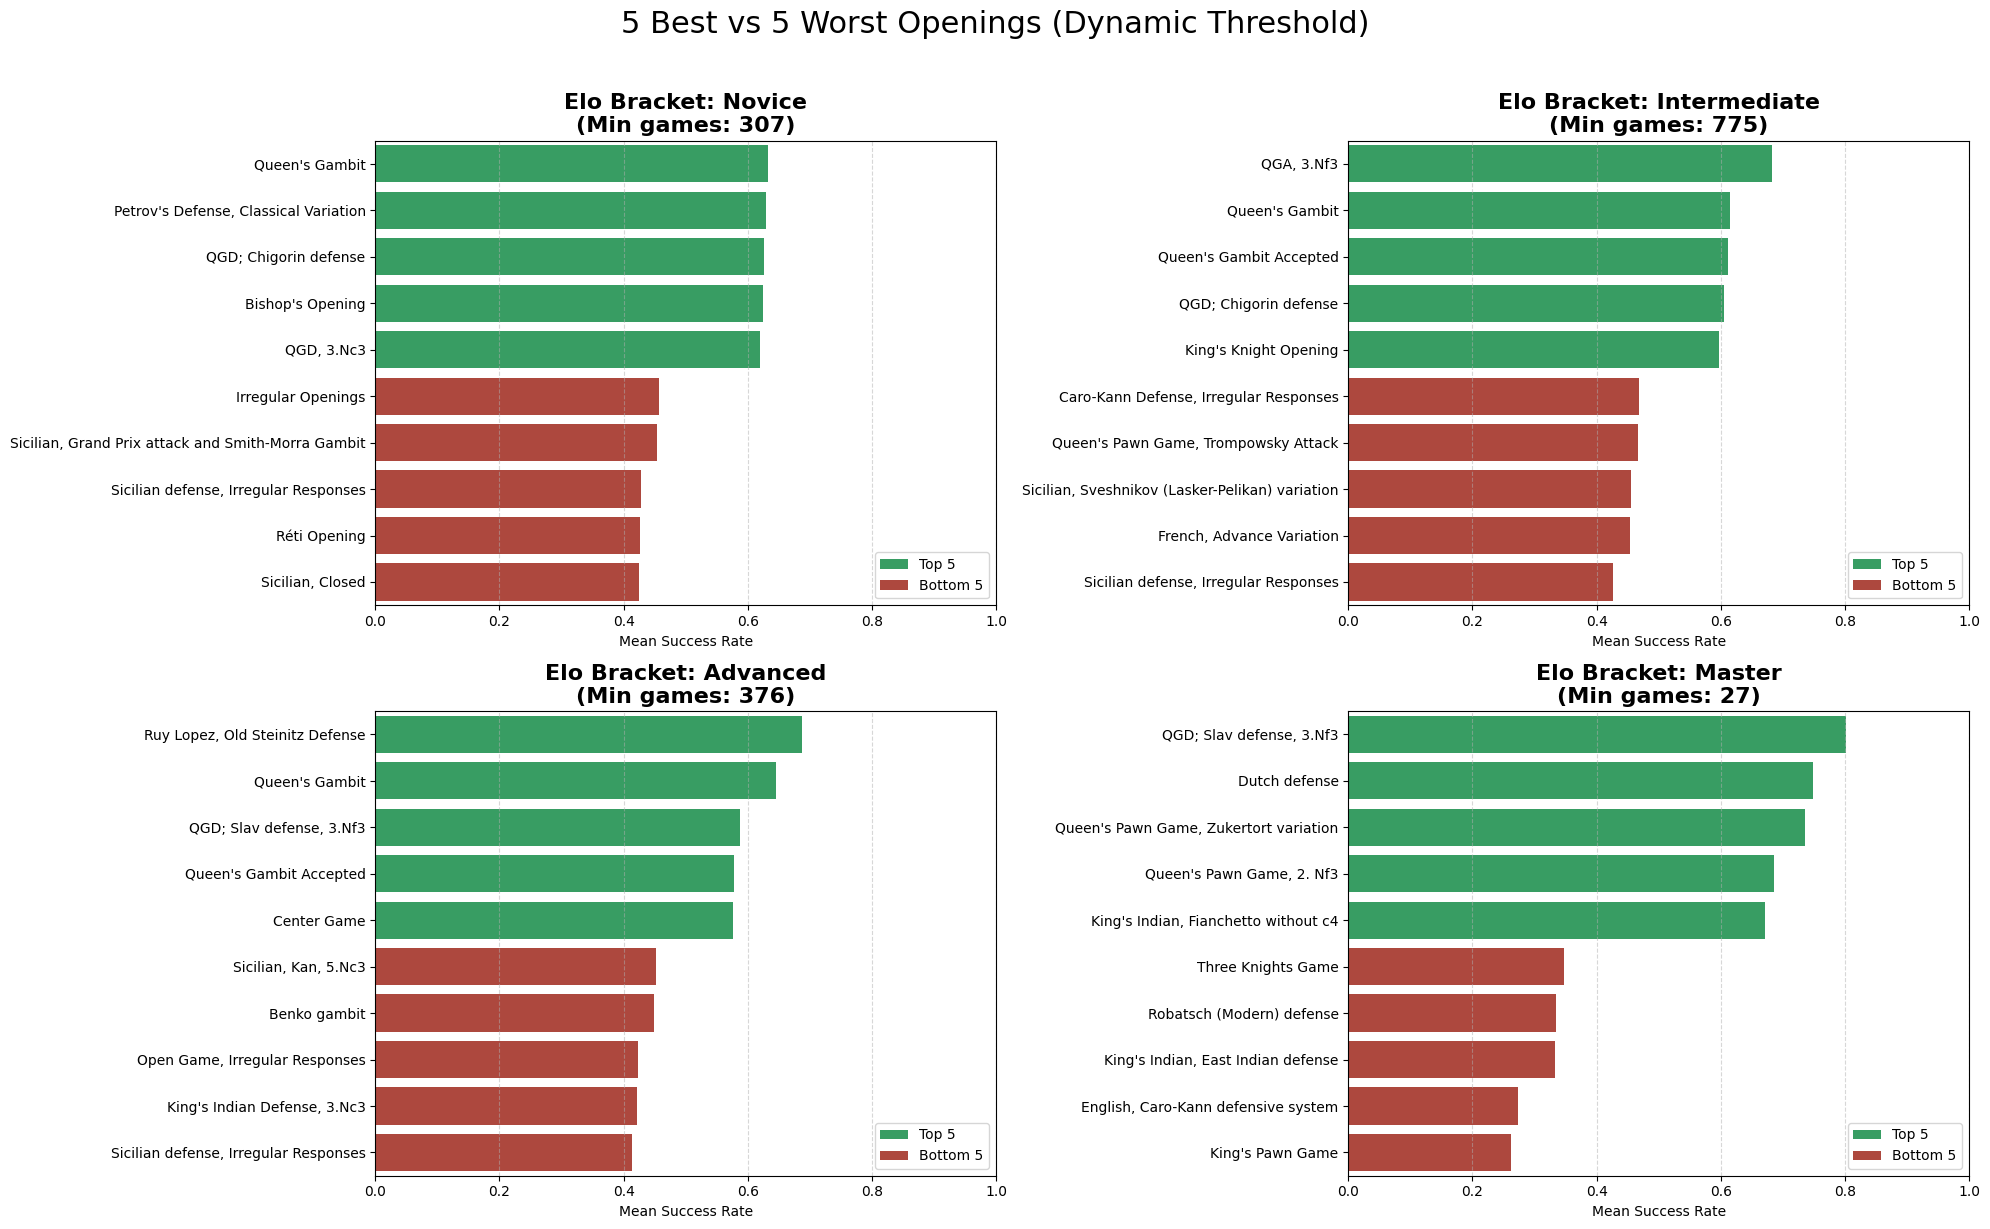

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate stats without filtering first
stats = X_train.groupby(['Elo_Bracket', 'FullName'])['ECO_Contextual'].agg(['mean', 'count']).reset_index()

brackets = stats['Elo_Bracket'].unique()
num_brackets = len(brackets)

fig, axes = plt.subplots(nrows=(num_brackets + 1) // 2, ncols=2, figsize=(20, 6 * ((num_brackets + 1) // 2)))
axes = axes.flatten()

for i, bracket in enumerate(brackets):
    bracket_data = stats[stats['Elo_Bracket'] == bracket].copy()
    
    # Dynamic Threshold: We only look at the top 20% most played openings in this bracket
    # This prevents the chart from breaking if your sample size is small
    min_games_dynamic = bracket_data['count'].quantile(0.80) 
    bracket_data = bracket_data[bracket_data['count'] >= min_games_dynamic].sort_values('mean', ascending=False)
    
    if len(bracket_data) >= 10:
        top_5 = bracket_data.head(5).copy()
        bottom_5 = bracket_data.tail(5).copy()
        
        top_5['Performance'] = 'Top 5'
        bottom_5['Performance'] = 'Bottom 5'
        plot_df = pd.concat([top_5, bottom_5])
        
        sns.barplot(
            data=plot_df, x='mean', y='FullName', hue='Performance', ax=axes[i],
            palette={'Top 5': '#27ae60', 'Bottom 5': '#c0392b'}, dodge=False
        )
        
        axes[i].set_title(f'Elo Bracket: {bracket}\n(Min games: {int(min_games_dynamic)})', fontsize=16, fontweight='bold')
        axes[i].set_xlabel('Mean Success Rate')
        axes[i].set_ylabel('')
        axes[i].set_xlim(0, 1)
        axes[i].grid(axis='x', linestyle='--', alpha=0.5)
        axes[i].legend(loc='lower right')
    else:
        axes[i].text(0.5, 0.5, 'Still not enough varied openings.\nCheck your train/test split size.', 
                     ha='center', va='center', fontsize=12)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('5 Best vs 5 Worst Openings (Dynamic Threshold)', fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

## Expected Score Pipeline (Leakage-Safe Train/Val/Test)

This section implements a reproducible pipeline with:
- expected-score target ( ,  .5, 1),
- strict train/validation/test split,
- out-of-fold target encoding,
- lightweight XGBoost hyperparameter tuning,
- calibration and slice diagnostics.


In [4]:
df = pd.read_csv(r"D:\Dev\Projects\Ureca\dataset\final_merged_data.csv")

In [5]:
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
N_FOLDS_OOF = 5
ALPHA_GRID = [5, 10, 20, 50]
N_TRIALS = 12
MAX_BOOST_ROUNDS = 2000
EARLY_STOPPING_ROUNDS = 100

random.seed(SEED)
np.random.seed(SEED)

print("Config loaded:")
print({
    "SEED": SEED,
    "splits": (TRAIN_SIZE, VAL_SIZE, TEST_SIZE),
    "N_FOLDS_OOF": N_FOLDS_OOF,
    "ALPHA_GRID": ALPHA_GRID,
    "N_TRIALS": N_TRIALS,
})


Config loaded:
{'SEED': 42, 'splits': (0.7, 0.15, 0.15), 'N_FOLDS_OOF': 5, 'ALPHA_GRID': [5, 10, 20, 50], 'N_TRIALS': 12}


In [6]:
# -----------------------------
# Helper functions
# -----------------------------

def map_expected_score(result_series: pd.Series) -> pd.Series:
    s = result_series.copy()

    if pd.api.types.is_numeric_dtype(s):
        out = pd.to_numeric(s, errors="coerce")
        out = out.where(out.isin([0.0, 0.5, 1.0]))
        return out

    s = s.astype(str).str.strip()
    mapping = {
        "1-0": 1.0,
        "0-1": 0.0,
        "1/2-1/2": 0.5,
        "0.5-0.5": 0.5,
        "1": 1.0,
        "0": 0.0,
        "0.5": 0.5,
    }
    return s.map(mapping)


def make_stratify_labels(y_expected: pd.Series) -> pd.Series:
    return y_expected.map({0.0: "loss", 0.5: "draw", 1.0: "win"})


def add_opening_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    df_out["ECO"] = df_out["ECO"].astype(str).fillna("UNK")
    df_out["FullName"] = df_out["FullName"].astype(str).fillna("Unknown")

    df_out["ECO_letter"] = df_out["ECO"].str[0].fillna("U")
    df_out["ECO_group"] = df_out["ECO"].str[:2].fillna("U0")

    bins = [0, 1200, 1400, 1600, 1800, 2000, 2200, 4000]
    labels = ["<1200", "1200-1399", "1400-1599", "1600-1799", "1800-1999", "2000-2199", "2200+"]
    df_out["Elo_Bracket"] = pd.cut(df_out["Avg_Elo"], bins=bins, labels=labels, include_lowest=True)
    df_out["Elo_Bracket"] = df_out["Elo_Bracket"].astype(str)

    return df_out


def smoothed_target_map(cat_series: pd.Series, y: pd.Series, alpha: float):
    tmp = pd.DataFrame({"cat": cat_series, "y": y})
    global_mean = tmp["y"].mean()
    stats = tmp.groupby("cat")["y"].agg(["count", "mean"])
    smooth = (stats["count"] * stats["mean"] + alpha * global_mean) / (stats["count"] + alpha)
    return smooth.to_dict(), float(global_mean)


def add_oof_target_encoding(train_df, val_df, test_df, cat_col, target_col, alpha, n_folds=5, seed=42):
    train_enc = pd.Series(index=train_df.index, dtype=float)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    strat_labels = make_stratify_labels(train_df[target_col])

    for tr_idx, oof_idx in skf.split(train_df, strat_labels):
        tr_part = train_df.iloc[tr_idx]
        oof_part = train_df.iloc[oof_idx]

        mapping, gm = smoothed_target_map(tr_part[cat_col], tr_part[target_col], alpha)
        train_enc.iloc[oof_idx] = oof_part[cat_col].map(mapping).fillna(gm)

    full_mapping, full_gm = smoothed_target_map(train_df[cat_col], train_df[target_col], alpha)
    val_enc = val_df[cat_col].map(full_mapping).fillna(full_gm)
    test_enc = test_df[cat_col].map(full_mapping).fillna(full_gm)

    return train_enc, val_enc, test_enc, full_mapping, full_gm


def make_model_matrices(train_df, val_df, test_df, alpha, seed=42):
    tr_eco, va_eco, te_eco, _, global_mean = add_oof_target_encoding(
        train_df, val_df, test_df, "ECO", "ExpectedScore", alpha, n_folds=N_FOLDS_OOF, seed=seed
    )
    tr_group, va_group, te_group, _, _ = add_oof_target_encoding(
        train_df, val_df, test_df, "ECO_group", "ExpectedScore", alpha, n_folds=N_FOLDS_OOF, seed=seed
    )

    train_x = train_df[["WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo"]].copy()
    val_x = val_df[["WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo"]].copy()
    test_x = test_df[["WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo"]].copy()

    train_x["ECO_TE"] = tr_eco
    val_x["ECO_TE"] = va_eco
    test_x["ECO_TE"] = te_eco

    train_x["ECO_GROUP_TE"] = tr_group
    val_x["ECO_GROUP_TE"] = va_group
    test_x["ECO_GROUP_TE"] = te_group

    train_x["ECO_TE_x_ELODIFF"] = train_x["ECO_TE"] * train_x["Elo_Diff"]
    val_x["ECO_TE_x_ELODIFF"] = val_x["ECO_TE"] * val_x["Elo_Diff"]
    test_x["ECO_TE_x_ELODIFF"] = test_x["ECO_TE"] * test_x["Elo_Diff"]

    all_letters = pd.concat([train_df["ECO_letter"], val_df["ECO_letter"], test_df["ECO_letter"]], axis=0)
    all_brackets = pd.concat([train_df["Elo_Bracket"], val_df["Elo_Bracket"], test_df["Elo_Bracket"]], axis=0)

    letter_dummies = pd.get_dummies(all_letters, prefix="ECO_L", dtype=int)
    bracket_dummies = pd.get_dummies(all_brackets, prefix="ELO_B", dtype=int)

    letter_train = letter_dummies.loc[train_df.index]
    letter_val = letter_dummies.loc[val_df.index]
    letter_test = letter_dummies.loc[test_df.index]

    bracket_train = bracket_dummies.loc[train_df.index]
    bracket_val = bracket_dummies.loc[val_df.index]
    bracket_test = bracket_dummies.loc[test_df.index]

    train_x = pd.concat([train_x, letter_train, bracket_train], axis=1)
    val_x = pd.concat([val_x, letter_val, bracket_val], axis=1)
    test_x = pd.concat([test_x, letter_test, bracket_test], axis=1)

    assert train_x.isnull().sum().sum() == 0, "NaNs in train features"
    assert val_x.isnull().sum().sum() == 0, "NaNs in val features"
    assert test_x.isnull().sum().sum() == 0, "NaNs in test features"

    return train_x, val_x, test_x, global_mean


def calibration_table(y_true, y_pred, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    df_cal = pd.DataFrame({"y": y_true, "p": y_pred})
    df_cal["bin"] = pd.cut(df_cal["p"], bins=bins, include_lowest=True)

    tab = df_cal.groupby("bin", observed=True).agg(
        pred_mean=("p", "mean"),
        obs_mean=("y", "mean"),
        n=("y", "size"),
    ).reset_index()

    tab = tab[tab["n"] > 0].copy()
    tab["abs_gap"] = (tab["pred_mean"] - tab["obs_mean"]).abs()
    ece = float((tab["abs_gap"] * tab["n"]).sum() / tab["n"].sum())
    return tab, ece


def eval_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    return {"rmse": rmse, "mae": float(mae), "mse_brier": float(mse)}


In [7]:
required_cols = ["ECO", "FullName", "WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo", "Result"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

pipeline_df = df[required_cols].copy()
pipeline_df["ExpectedScore"] = map_expected_score(pipeline_df["Result"])
pipeline_df = pipeline_df.dropna(subset=["ExpectedScore", "WhiteElo", "BlackElo", "Elo_Diff", "Avg_Elo", "ECO", "FullName"]).copy()
pipeline_df = pipeline_df[pipeline_df["ExpectedScore"].isin([0.0, 0.5, 1.0])].copy()
pipeline_df = add_opening_features(pipeline_df)

target_values = sorted(pipeline_df["ExpectedScore"].unique().tolist())
assert set(target_values).issubset({0.0, 0.5, 1.0}), "Unexpected target values found"

print("Target values present:", target_values)
print("Rows available for expected-score model:", len(pipeline_df))
print("Class balance:")
print(pipeline_df["ExpectedScore"].value_counts(normalize=True).sort_index())

strat_all = make_stratify_labels(pipeline_df["ExpectedScore"])

train_df, temp_df = train_test_split(
    pipeline_df,
    test_size=(VAL_SIZE + TEST_SIZE),
    random_state=SEED,
    stratify=strat_all,
)

temp_strat = make_stratify_labels(temp_df["ExpectedScore"])
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_strat,
)

print(f"Train size: {len(train_df):,} ({len(train_df)/len(pipeline_df):.2%})")
print(f"Val size:   {len(val_df):,} ({len(val_df)/len(pipeline_df):.2%})")
print(f"Test size:  {len(test_df):,} ({len(test_df)/len(pipeline_df):.2%})")


ValueError: Missing required columns in df: ['Elo_Diff', 'Avg_Elo']

In [8]:
@dataclass
class TuneResult:
    alpha: float
    params: dict
    best_iteration: int
    val_metrics: dict
    val_ece: float
    model: object


def random_params(rng):
    return {
        "objective": "reg:logistic",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "seed": SEED,
        "eta": float(rng.choice([0.02, 0.03, 0.05, 0.08, 0.1])),
        "max_depth": int(rng.choice([3, 4, 5, 6, 7])),
        "min_child_weight": float(rng.choice([1, 2, 4, 6, 8])),
        "gamma": float(rng.choice([0.0, 0.1, 0.3, 0.5, 1.0])),
        "subsample": float(rng.choice([0.7, 0.8, 0.9, 1.0])),
        "colsample_bytree": float(rng.choice([0.6, 0.7, 0.8, 0.9, 1.0])),
        "reg_lambda": float(rng.choice([0.5, 1.0, 2.0, 5.0, 10.0])),
    }


rng = np.random.default_rng(SEED)

best = None
all_trials = []

for alpha in ALPHA_GRID:
    X_train, X_val, _, _ = make_model_matrices(train_df, val_df, test_df, alpha=alpha, seed=SEED)

    y_train = train_df["ExpectedScore"].values
    y_val = val_df["ExpectedScore"].values

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    for _ in range(N_TRIALS):
        params = random_params(rng)

        model = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=MAX_BOOST_ROUNDS,
            evals=[(dtrain, "train"), (dval, "val")],
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbose_eval=False,
        )

        val_pred = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
        val_pred = np.clip(val_pred, 0.0, 1.0)

        val_metrics = eval_metrics(y_val, val_pred)
        _, val_ece = calibration_table(y_val, val_pred, n_bins=10)

        result = TuneResult(
            alpha=alpha,
            params=params,
            best_iteration=int(model.best_iteration),
            val_metrics=val_metrics,
            val_ece=val_ece,
            model=model,
        )
        all_trials.append(result)

        if best is None:
            best = result
        else:
            b_rmse = best.val_metrics["rmse"]
            r_rmse = result.val_metrics["rmse"]
            if (r_rmse < b_rmse) or (np.isclose(r_rmse, b_rmse) and result.val_ece < best.val_ece):
                best = result

print("Tuning complete.")
print(f"Total trials: {len(all_trials)}")
print("Best alpha:", best.alpha)
print("Best params:", best.params)
print("Best iteration:", best.best_iteration)
print("Best validation metrics:", best.val_metrics)
print("Best validation ECE:", round(best.val_ece, 6))


NameError: name 'train_df' is not defined

In [ ]:
X_train_b, X_val_b, _, _ = make_model_matrices(train_df, val_df, test_df, alpha=best.alpha, seed=SEED)
y_val = val_df["ExpectedScore"].values

dval_b = xgb.DMatrix(X_val_b, label=y_val)
val_pred = best.model.predict(dval_b, iteration_range=(0, best.best_iteration + 1))
val_pred = np.clip(val_pred, 0.0, 1.0)

val_metrics = eval_metrics(y_val, val_pred)
val_cal, val_ece = calibration_table(y_val, val_pred, n_bins=10)

print("Validation metrics:", val_metrics)
print("Validation ECE:", round(val_ece, 6))

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(val_cal["pred_mean"], val_cal["obs_mean"], marker="o", label="Validation")
plt.xlabel("Predicted expected score (bin mean)")
plt.ylabel("Observed expected score (bin mean)")
plt.title("Calibration Curve - Validation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
trainval_df = pd.concat([train_df, val_df], axis=0).copy()

X_trainval, _, X_test_final, _ = make_model_matrices(
    trainval_df,
    val_df,
    test_df,
    alpha=best.alpha,
    seed=SEED,
)

y_trainval = trainval_df["ExpectedScore"].values
y_test = test_df["ExpectedScore"].values

dtrainval = xgb.DMatrix(X_trainval, label=y_trainval)
dtest = xgb.DMatrix(X_test_final, label=y_test)

final_model = xgb.train(
    params=best.params,
    dtrain=dtrainval,
    num_boost_round=best.best_iteration + 1,
    evals=[(dtrainval, "trainval")],
    verbose_eval=False,
)

test_pred = final_model.predict(dtest)
test_pred = np.clip(test_pred, 0.0, 1.0)

test_metrics = eval_metrics(y_test, test_pred)
test_cal, test_ece = calibration_table(y_test, test_pred, n_bins=10)

print("--- Final Test Evaluation (untouched during tuning) ---")
print("Best alpha:", best.alpha)
print("Best params:", best.params)
print("Best iteration used:", best.best_iteration + 1)
print("Test metrics:", test_metrics)
print("Test ECE:", round(test_ece, 6))

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(test_cal["pred_mean"], test_cal["obs_mean"], marker="o", label="Test")
plt.xlabel("Predicted expected score (bin mean)")
plt.ylabel("Observed expected score (bin mean)")
plt.title("Calibration Curve - Test")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
test_diag = test_df[["ECO", "ECO_letter", "ECO_group", "Elo_Bracket", "Avg_Elo", "ExpectedScore"]].copy()
test_diag["pred"] = test_pred
test_diag["residual"] = test_diag["ExpectedScore"] - test_diag["pred"]
test_diag["abs_error"] = test_diag["residual"].abs()

by_bracket = test_diag.groupby("Elo_Bracket", observed=True).agg(
    n=("ExpectedScore", "size"),
    y_mean=("ExpectedScore", "mean"),
    pred_mean=("pred", "mean"),
    mae=("abs_error", "mean"),
    rmse=("residual", lambda x: float(np.sqrt(np.mean(np.square(x))))),
).reset_index().sort_values("n", ascending=False)

by_opening_letter = test_diag.groupby("ECO_letter", observed=True).agg(
    n=("ExpectedScore", "size"),
    y_mean=("ExpectedScore", "mean"),
    pred_mean=("pred", "mean"),
    mae=("abs_error", "mean"),
    rmse=("residual", lambda x: float(np.sqrt(np.mean(np.square(x))))),
).reset_index().sort_values("n", ascending=False)

print("Test residual slices by Elo bracket:")
display(by_bracket)

print("Test residual slices by ECO letter:")
display(by_opening_letter)

print("\\nSanity check (RMSE):")
print({"validation_rmse": val_metrics["rmse"], "test_rmse": test_metrics["rmse"]})
